In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

In [2]:
envs = ["atari_battle_zone", "atari_double_dunk", "atari_phoenix", "atari_this_game", "atari_battle_zone", "box2d_lunar_lander", "box2d_continuous_lunar_lander", "box2d_bipedal_walker", "cc_acrobot", "cc_cartpole", "cc_mountain_car", "cc_continuous_mountain_car", "cc_pendulum", "minigrid_door_key", "minigrid_empty_random", "minigrid_four_rooms", "minigrid_unlock", "brax_ant", "brax_halfcheetah", "brax_hopper", "brax_humanoid"]
algos = ["ppo", "dqn", "sac"]

data = []
for env in envs:
    for algo in algos:
        try:
            partial_data = pd.read_csv(f"arlbench_data/256_10/{env}_{algo}.csv")
            partial_data["env_name"] = env
            partial_data["algorithm"] = algo
            data.append(partial_data)
        except FileNotFoundError:
            continue
data = pd.concat(data)

## 1. Normalize performance values

### a) similarly to last_performance (per alg & env)

In [3]:
from sklearn.linear_model import LinearRegression

In [4]:
# normalization coefficients 
# {"{alg}-{env}": (coef, intercept)} 
# where normalized = coef * unnormalized + intercept

normalization_coefficients = {}

for env in data["env_name"].unique():
    for alg in data["algorithm"].unique():

        data_subset = data[(data["algorithm"] == alg) & (data["env_name"] == env)]

        try:
            X = data_subset[["last_performance_unnormalized"]]
            y = data_subset["last_performance"]
            reg = LinearRegression().fit(X, y)
            normalization_coefficients[f"{alg}-{env}"] = (reg.coef_[0], reg.intercept_)
        except ValueError:
            # print(f"Not enough data for {env} and {alg}")
            continue

### b) per env, but cross algorithms

In [5]:
## Alternatively: Normalize Cross algorithms in a single environment

normalization_coefficients_cross_alg = {}

for env in data["env_name"].unique():

    env_data = data[(data["env_name"] == env)]

    max_performance = env_data["performance"].max()
    min_performance = env_data["performance"].min()

    coef = 1 / (max_performance - min_performance) if max_performance != min_performance else 1.0
    intercept = -min_performance * coef

    normalization_coefficients_cross_alg[env] = (coef, intercept)

## 2. Calc performance profiles

In [ ]:
def compute_performance_profile(df, 
                                tau_values,
                                norm_d: dict,
                                key: str = "alg-env"
                                ):
    """
    Compute performance profile based on:
    (1/M) * sum_m (1/HS) * sum_h sum_s 1_{x_{m,h,s} > tau}
    
    Where:
    - m = env_name
    - h = config_id
    - s = seed
    """
    results = []
    
    for algo in df["algorithm"].unique():
        algo_data = df[df["algorithm"] == algo]
        
        for tau in tau_values:
            env_scores = []
            
            for env in algo_data["env_name"].unique():
                env_data = algo_data[algo_data["env_name"] == env]
                
                # Count how many (config, seed) pairs exceed tau
                H = env_data["config_id"].nunique()
                S = env_data.groupby("config_id").size().max()  # seeds per config
                HS = len(env_data)  # total (config, seed) pairs

                coef = norm_d[f"{algo}-{env}"][0] if key == "alg-env" else norm_d[env][0]
                intercept = norm_d[f"{algo}-{env}"][1] if key == "alg-env" else norm_d[env][1]
                
                indicator_sum = (
                    (env_data["performance"] * coef + intercept)
                    > tau
                    ).sum()
                env_score = indicator_sum / HS
                env_scores.append(env_score)
            
            # Average over environments
            mean_score = np.mean(env_scores)
            results.append({
                "algorithm": algo,
                "tau": tau,
                "performance_profile": mean_score
            })
    
    return pd.DataFrame(results)


In [11]:
def compute_performance_profile(
    df, 
    tau_values,
    norm_d: dict,
    key: str = "alg-env",
    n_bootstrap: int = 50,
    confidence: float = 0.95
):
    """
    Compute performance profile with bootstrapping:
    - Stratified over envs (always include all envs)
    - Bootstrapped over (config_id, seed) pairs within each env
    
    Returns DataFrame with mean, lower CI, and upper CI.
    """
    results = []
    alpha = (1 - confidence) / 2
    
    for algo in df["algorithm"].unique():
        algo_data = df[df["algorithm"] == algo]
        envs = algo_data["env_name"].unique()
        
        for tau in tau_values:
            bootstrap_scores = []
            
            for _ in range(n_bootstrap):
                env_scores = []
                
                for env in envs:
                    env_data = algo_data[algo_data["env_name"] == env]
                    
                    # Bootstrap sample within this env (sample with replacement)
                    boot_sample = env_data.sample(n=len(env_data), replace=True)
                    
                    HS = len(boot_sample)
                    
                    coef = norm_d[f"{algo}-{env}"][0] if key == "alg-env" else norm_d[env][0]
                    intercept = norm_d[f"{algo}-{env}"][1] if key == "alg-env" else norm_d[env][1]
                    
                    indicator_sum = (
                        (boot_sample["performance"] * coef + intercept) > tau
                    ).sum()
                    env_score = indicator_sum / HS
                    env_scores.append(env_score)
                
                # Average over environments (stratified)
                bootstrap_scores.append(np.mean(env_scores))
            
            # Compute statistics
            mean_score = np.mean(bootstrap_scores)
            ci_lower = np.percentile(bootstrap_scores, alpha * 100)
            ci_upper = np.percentile(bootstrap_scores, (1 - alpha) * 100)
            
            results.append({
                "algorithm": algo,
                "tau": tau,
                "performance_profile": mean_score,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper
            })
    
    return pd.DataFrame(results)

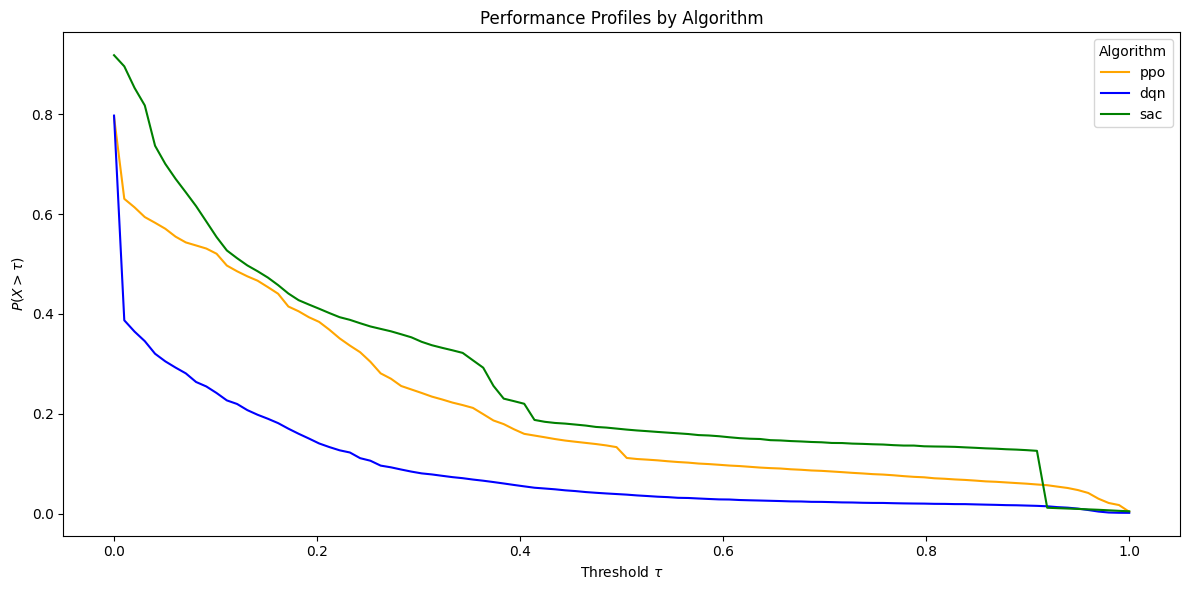

In [12]:
# Define tau range based on data
tau_min = 0
tau_max = 1
tau_values = np.linspace(tau_min, tau_max, 100)

# Compute performance profiles
performance_profiles = compute_performance_profile(data, tau_values, normalization_coefficients)

# Plot
algo_colors = {"sac": "green", "ppo": "orange", "dqn": "blue"}

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=performance_profiles,
    x="tau",
    y="performance_profile",
    hue="algorithm",
    palette=algo_colors
)
plt.xlabel(r"Threshold $\tau$")
plt.ylabel(r"$P( X > \tau)$")
plt.title("Performance Profiles by Algorithm")
plt.legend(title="Algorithm")
plt.tight_layout()

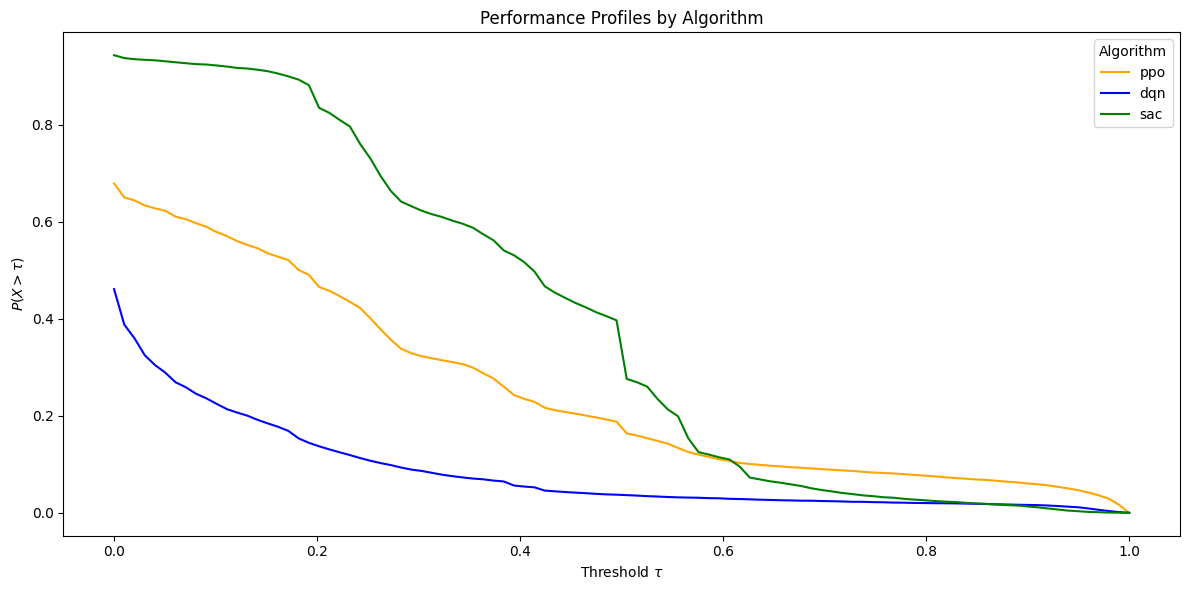

In [13]:
# Define tau range based on data
tau_min = 0
tau_max = 1
tau_values = np.linspace(tau_min, tau_max, 100)

# Compute performance profiles
performance_profiles = compute_performance_profile(data, tau_values, normalization_coefficients_cross_alg, key="env")

# Plot
algo_colors = {"sac": "green", "ppo": "orange", "dqn": "blue"}

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=performance_profiles,
    x="tau",
    y="performance_profile",
    hue="algorithm",
    palette=algo_colors
)
plt.xlabel(r"Threshold $\tau$")
plt.ylabel(r"$P( X > \tau)$")
plt.title("Performance Profiles by Algorithm")
plt.legend(title="Algorithm")
plt.tight_layout()